#### Rating histogram

Fetching problems with tag 0-3500 from Codeforces API...
Fetched 10898 problems
Building tag frequencies per rating bucket...

Bucket 0-1000: 2793 tag occurrences across 34 distinct tags
  implementation            640
  math                      553
  greedy                    488
  brute force               240
  constructive algorithms   240
  sortings                  155
  strings                   154
  number theory             71
  dp                        37
  games                     33

Bucket 1000-1300: 2922 tag occurrences across 33 distinct tags
  implementation            554
  greedy                    494
  math                      425
  brute force               273
  constructive algorithms   259
  sortings                  190
  strings                   111
  number theory             93
  dp                        85
  binary search             79

Bucket 1300-1600: 3677 tag occurrences across 35 distinct tags
  greedy                    543
  implementation   

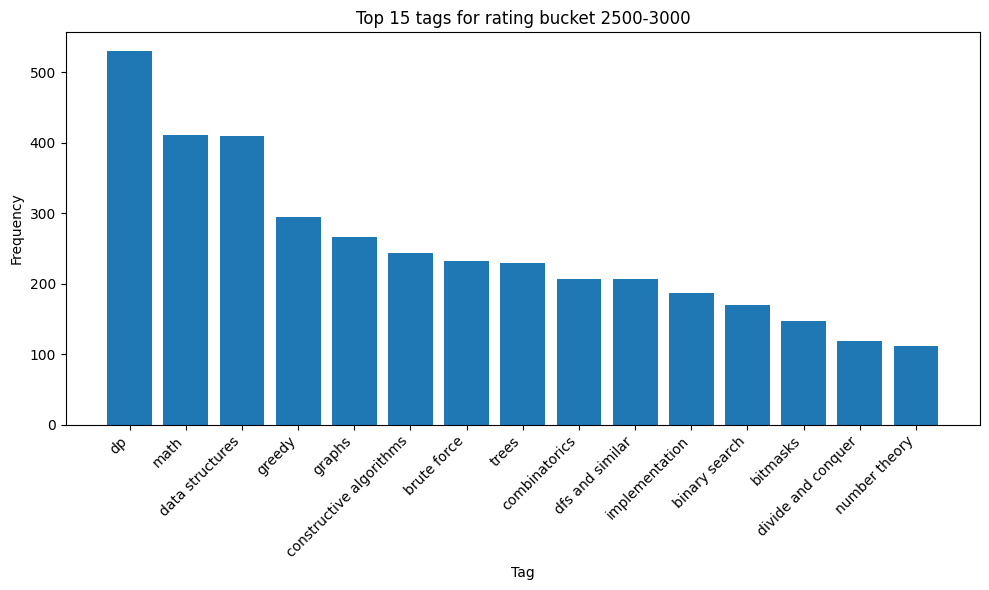

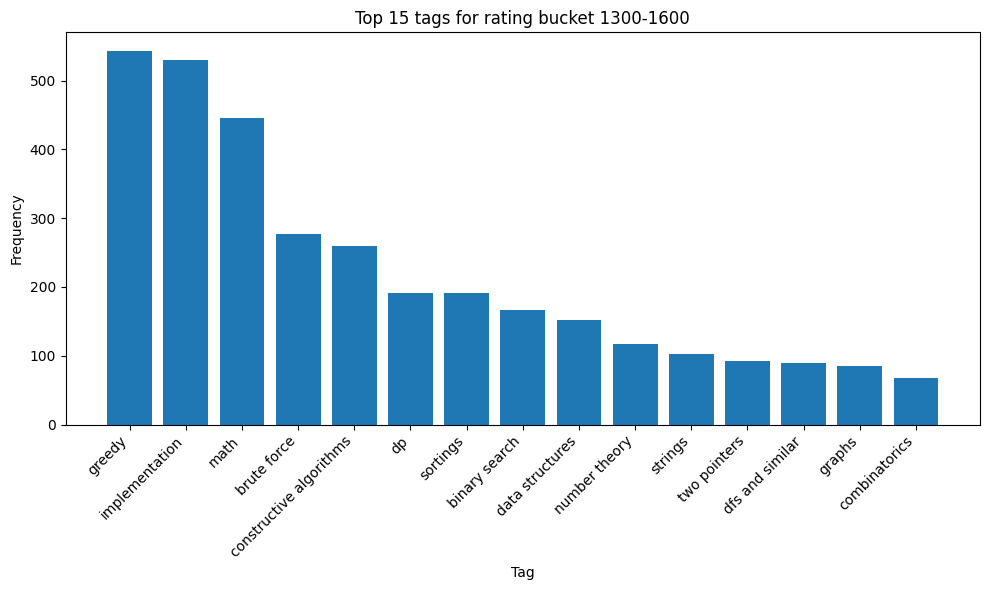

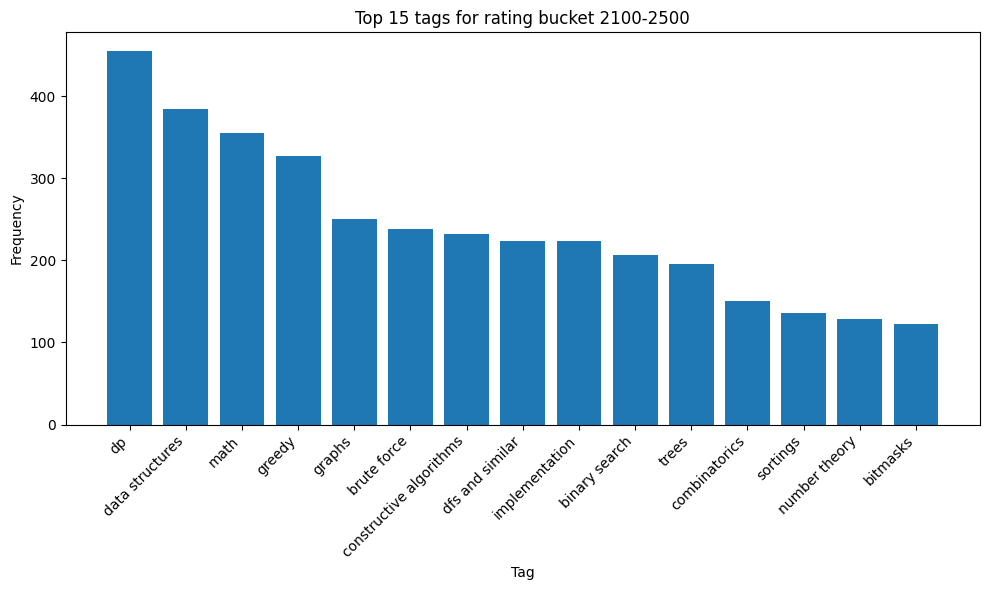

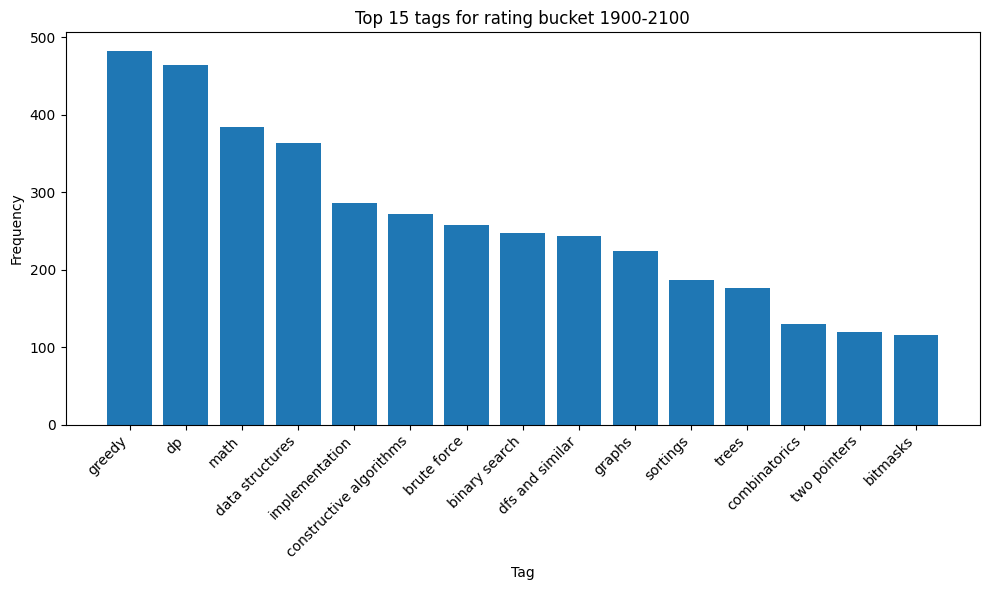

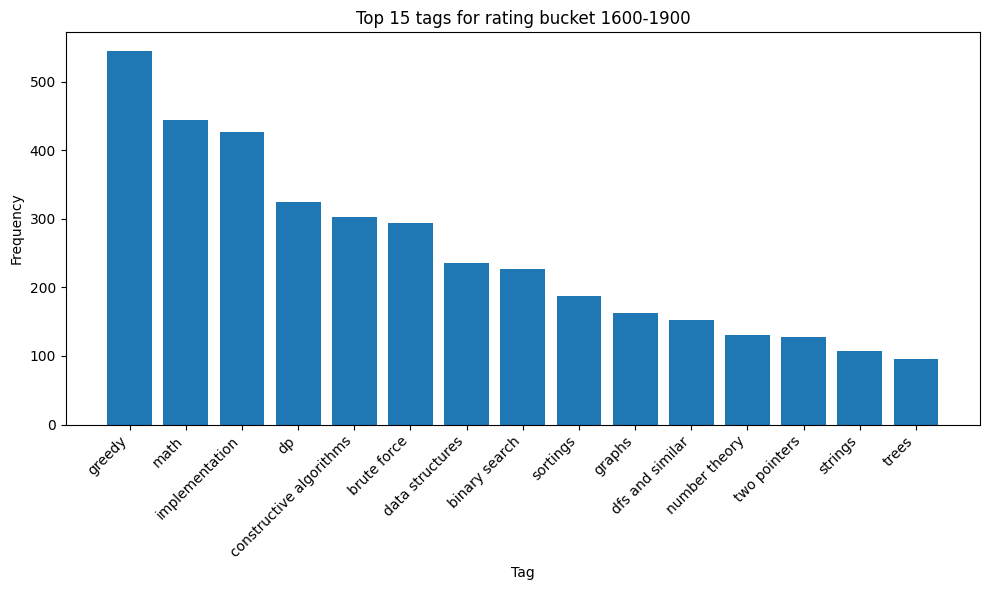

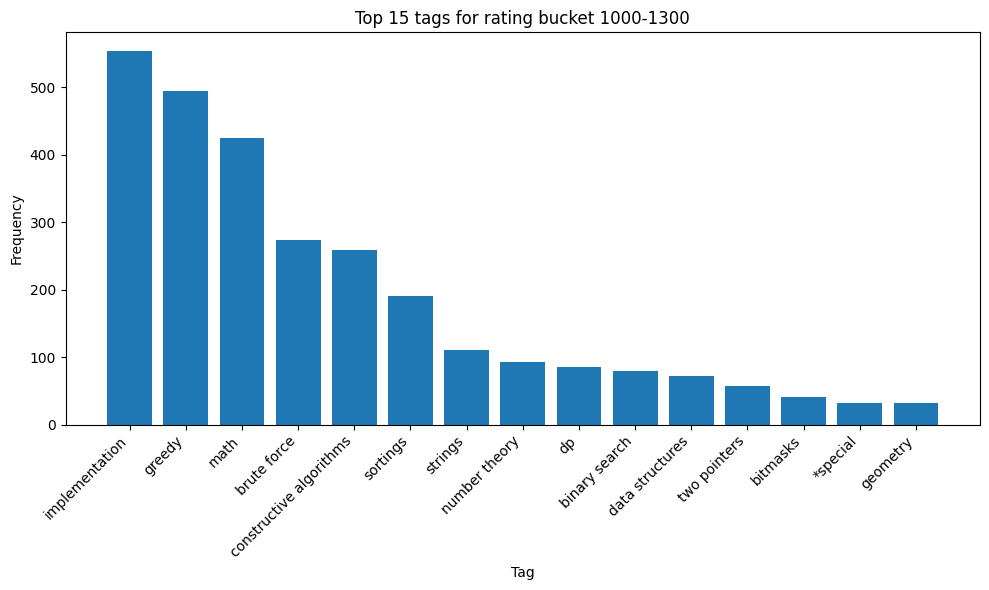

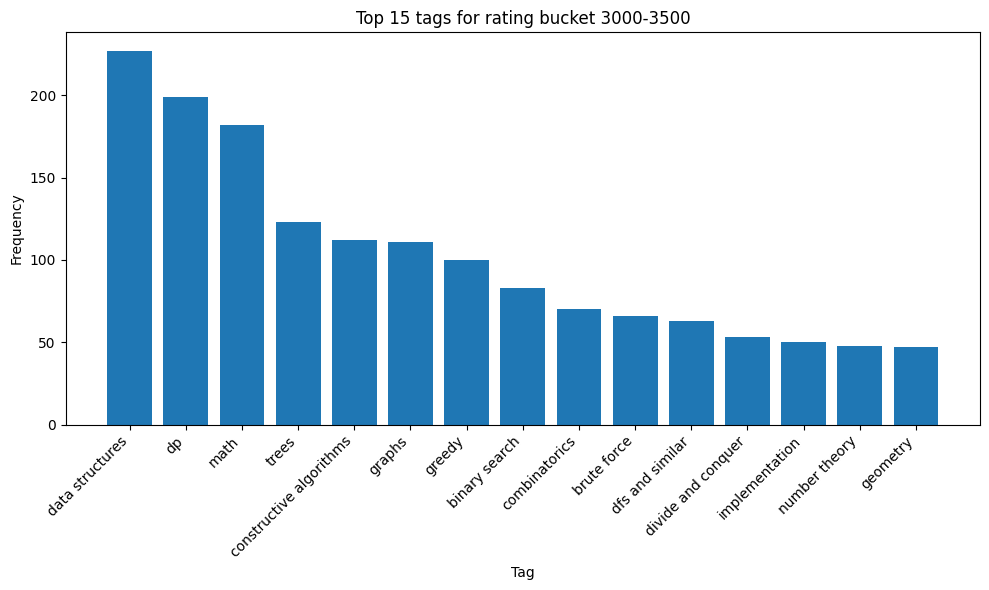

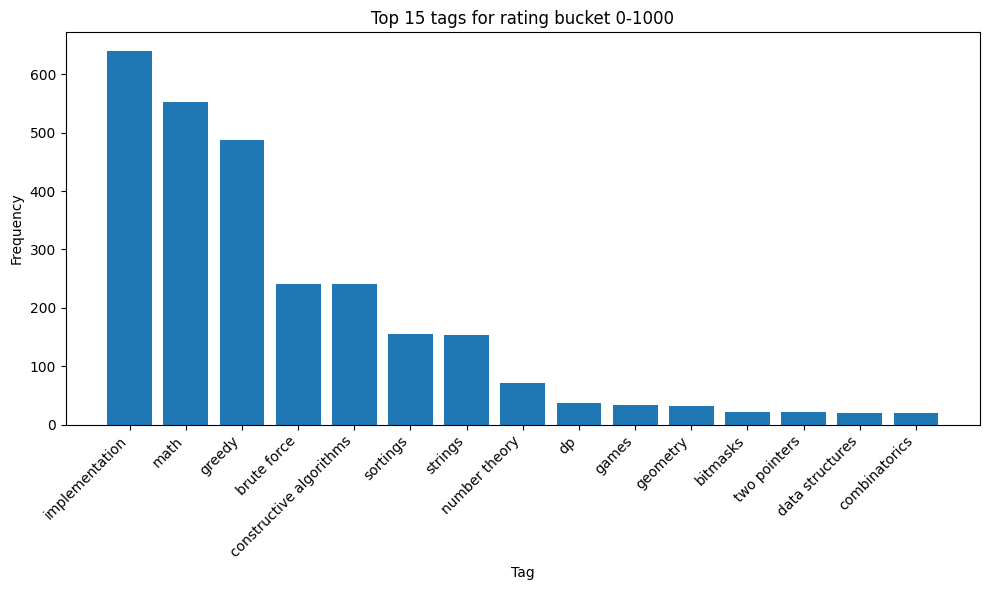

In [3]:
import requests
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

BASE_URL = "https://codeforces.com/api/problemset.problems"

# Rating buckets: (label, lower_bound_inclusive, upper_bound_exclusive)
RATING_BUCKETS = [
    ("0-1000", 0, 1000),
    ("1000-1300", 1000, 1300),
    ("1300-1600", 1300, 1600),
    ("1600-1900", 1600, 1900),
    ("1900-2100", 1900, 2101),  # 2100 inclusive
    ("2100-2500", 2100, 2500),  
    ("2500-3000", 2500, 3000),  
    ("3000-3500", 3000, 3500),  #
]

def get_bucket_label(rating: int):
    """Return the label of the bucket that rating belongs to, or None if outside."""
    if rating is None:
        return None
    for label, lo, hi in RATING_BUCKETS:
        if lo <= rating < hi:
            return label
    return None

def fetch_problems_0_3500():
    """
    Uses Codeforces API to fetch problems with tag '0-3500' (i.e., problems
    up to 3500 difficulty).
    """
    resp = requests.get(BASE_URL)
    resp.raise_for_status()
    data = resp.json()

    if data.get("status") != "OK":
        raise RuntimeError(f"Codeforces API error: {data}")

    return data["result"]["problems"]

def build_tag_frequencies_by_bucket(problems):
    """
    Given a list of problems from the API, return:
        bucket_to_tag_counter: dict[label -> Counter(tag -> freq)]
    """
    bucket_to_tag_counter: dict[str, Counter] = defaultdict(Counter)

    for p in problems:
        rating = p.get("rating")
        tags = p.get("tags", [])
        bucket_label = get_bucket_label(rating)
        if bucket_label is None:
            continue  # skip problems outside buckets or without rating

        for t in tags:
            bucket_to_tag_counter[bucket_label][t] += 1

    return bucket_to_tag_counter

def plot_tag_barcharts(bucket_to_tag_counter, top_n: int = 15):
    """
    For each bucket, show a bar chart of the top_n tags by frequency.
    """
    for bucket_label, counter in bucket_to_tag_counter.items():
        if not counter:
            print(f"No data for bucket {bucket_label}, skipping plot.")
            continue

        # Take top N tags
        most_common = counter.most_common(top_n)
        tags = [t for t, _ in most_common]
        freqs = [f for _, f in most_common]

        plt.figure(figsize=(10, 6))
        plt.bar(tags, freqs)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Top {top_n} tags for rating bucket {bucket_label}")
        plt.xlabel("Tag")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        # Or save instead of show:
        # plt.savefig(f"tags_{bucket_label}.png", bbox_inches="tight")

def main():
    print("Fetching problems with tag 0-3500 from Codeforces API...")
    problems = fetch_problems_0_3500()
    print(f"Fetched {len(problems)} problems")

    print("Building tag frequencies per rating bucket...")
    bucket_to_tag_counter = build_tag_frequencies_by_bucket(problems)

    # Print some stats:
    for label, _, _ in RATING_BUCKETS:
        cnt = bucket_to_tag_counter.get(label, Counter())
        print(f"\nBucket {label}: {sum(cnt.values())} tag occurrences across {len(cnt)} distinct tags")
        for tag, freq in cnt.most_common(10):
            print(f"  {tag:25s} {freq}")

    print("\nPlotting bar charts...")
    plot_tag_barcharts(bucket_to_tag_counter, top_n=15)

if __name__ == "__main__":
    main()

#### Total questions in a rating range

In [4]:
import requests

def get_problem_count(target_tag, min_rating, max_rating):
    """
    Counts Codeforces problems with a specific tag within a rating range.
    """
    url = "https://codeforces.com/api/problemset.problems"
    
    # We request all problems with the specific tag to minimize data fetching
    params = {"tags": target_tag}
    
    print(f"Fetching problems with tag '{target_tag}'...")
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status() # Check for HTTP errors
        data = response.json()
        
        if data["status"] != "OK":
            print(f"Error from Codeforces: {data['comment']}")
            return

        problems = data["result"]["problems"]
        count = 0
        
        for p in problems:
            # Some problems might not have a rating (e.g., unrated), so we check 'rating' in p
            if "rating" in p:
                if min_rating <= p["rating"] < max_rating:
                    count += 1
        
        return count

    except requests.exceptions.RequestException as e:
        print(f"Network error: {e}")
        return 0

# --- Configuration ---
TAG = "graphs"       # e.g., 'dp', 'greedy', 'implementation', 'graphs'
MIN_RATING = 0       # Lower bound (inclusive)
MAX_RATING = 2100    # Upper bound (exclusive)

# --- Execution ---
if __name__ == "__main__":
    result = get_problem_count(TAG, MIN_RATING, MAX_RATING)
    
    if result is not None:
        print("-" * 30)
        print(f"Topic:  {TAG}")
        print(f"Range:  {MIN_RATING} <= rating < {MAX_RATING}")
        print(f"Count:  {result}")
        print("-" * 30)

Fetching problems with tag 'graphs'...
------------------------------
Topic:  graphs
Range:  0 <= rating < 2100
Count:  423
------------------------------


#### No of Questions of a given range of topic among entire range

In [5]:
import requests
from collections import defaultdict

def get_detailed_breakdown(target_topics):
    """
    Fetches all problems and generates a rating breakdown for specific topics.
    """
    url = "https://codeforces.com/api/problemset.problems"
    
    print("Fetching data from Codeforces API...")
    try:
        # Fetch ALL problems once
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        
        if data["status"] != "OK":
            print(f"Error: {data['comment']}")
            return

        all_problems = data["result"]["problems"]
        
        # Structure: stats[topic][rating] = count
        stats = defaultdict(lambda: defaultdict(int))
        
        # Process problems
        print(f"Processing {len(all_problems)} problems...")
        
        for p in all_problems:
            if "rating" not in p: continue
            
            rating = p["rating"]
            problem_tags = p["tags"]
            
            # Check if this problem belongs to any of the requested topics
            for tag in problem_tags:
                if tag in target_topics:
                    stats[tag][rating] += 1
                    
        return stats

    except requests.exceptions.RequestException as e:
        print(f"Network error: {e}")
        return None

def print_report(stats, topics):
    print("\n" + "="*50)
    print(f"{'TOPIC ANALYSIS':^50}")
    print("="*50)

    for topic in topics:
        if topic not in stats:
            print(f"\nTopic: {topic} (0 problems found or invalid tag)")
            continue

        print(f"\n>> Topic: {topic.upper()}")
        print(f"{'Rating':<10} | {'Count':<10}")
        print("-" * 25)
        
        # Sort ratings for this topic
        sorted_ratings = sorted(stats[topic].keys())
        total_count = 0
        
        for rating in sorted_ratings:
            count = stats[topic][rating]
            total_count += count
            print(f"{rating:<10} | {count:<10}")
            
        print("-" * 25)
        print(f"{'TOTAL':<10} | {total_count:<10}")

# --- CONFIGURATION ---
# List the topics you want to analyze exactly as Codeforces names them
# Common tags: 'implementation', 'dp', 'math', 'greedy', 'brute force', 
# 'data structures', 'constructive algorithms', 'graphs', 'sortings', 
# 'binary search', 'dfs and similar', 'trees', 'strings', 'number theory'

MY_TOPICS = ["graphs", "dp", "constructive algorithms"]

# --- RUN ---
if __name__ == "__main__":
    results = get_detailed_breakdown(MY_TOPICS)
    
    if results:
        print_report(results, MY_TOPICS)

Fetching data from Codeforces API...
Processing 10898 problems...

                  TOPIC ANALYSIS                  

>> Topic: GRAPHS
Rating     | Count     
-------------------------
800        | 5         
900        | 3         
1000       | 3         
1100       | 8         
1200       | 11        
1300       | 25        
1400       | 27        
1500       | 33        
1600       | 43        
1700       | 66        
1800       | 53        
1900       | 77        
2000       | 69        
2100       | 78        
2200       | 76        
2300       | 79        
2400       | 95        
2500       | 71        
2600       | 65        
2700       | 49        
2800       | 53        
2900       | 28        
3000       | 44        
3100       | 16        
3200       | 23        
3300       | 15        
3400       | 13        
3500       | 32        
-------------------------
TOTAL      | 1160      

>> Topic: DP
Rating     | Count     
-------------------------
800        | 23        
900 

#### No of Questions of a given range of topic among given range

In [25]:
import requests
from collections import defaultdict

# --- CONFIGURATION ---
MY_TOPICS = [
    "graphs",
    "data structures",
    "dp",
    "trees",
    "greedy",
    "implementation",
    "brute force",
    "constructive algorithms",
    "math",
]  # Add tags here
MIN_RANGE = 1200  # Inclusive
MAX_RANGE = 1500  # Inclusive


def get_detailed_breakdown(target_topics, min_r, max_r):
    """
    Fetches all problems and generates a rating breakdown for specific topics
    within a specific rating range.
    """
    url = "https://codeforces.com/api/problemset.problems"

    print("Fetching data from Codeforces API...")
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        if data["status"] != "OK":
            print(f"Error: {data['comment']}")
            return

        all_problems = data["result"]["problems"]

        # Structure: stats[topic][rating] = count
        stats = defaultdict(lambda: defaultdict(int))

        print(f"Processing {len(all_problems)} problems...")

        for p in all_problems:
            if "rating" not in p:
                continue

            rating = p["rating"]

            # Filter by Range
            if not (min_r <= rating <= max_r):
                continue

            problem_tags = p["tags"]

            # Check if this problem belongs to any of the requested topics
            for tag in problem_tags:
                if tag in target_topics:
                    stats[tag][rating] += 1

        return stats

    except requests.exceptions.RequestException as e:
        print(f"Network error: {e}")
        return None


def print_report(stats, topics, min_r, max_r):
    print("\n" + "=" * 50)
    print(f"{'TOPIC ANALYSIS':^50}")
    print(f"{f'Range: {min_r} - {max_r}':^50}")
    print("=" * 50)

    for topic in topics:
        if topic not in stats:
            print(f"\n>> Topic: {topic.upper()}")
            print("   No problems found in this range.")
            continue

        print(f"\n>> Topic: {topic.upper()}")
        print(f"{'Rating':<10} | {'Count':<10}")
        print("-" * 25)

        # Sort ratings for this topic
        sorted_ratings = sorted(stats[topic].keys())
        total_count = 0

        for rating in sorted_ratings:
            count = stats[topic][rating]
            total_count += count
            print(f"{rating:<10} | {count:<10}")

        print("-" * 25)
        print(f"{'TOTAL':<10} | {total_count:<10}")


# --- RUN ---
if __name__ == "__main__":
    results = get_detailed_breakdown(MY_TOPICS, MIN_RANGE, MAX_RANGE)

    if results is not None:
        print_report(results, MY_TOPICS, MIN_RANGE, MAX_RANGE)

Fetching data from Codeforces API...
Processing 10898 problems...

                  TOPIC ANALYSIS                  
                Range: 1200 - 1500                

>> Topic: GRAPHS
Rating     | Count     
-------------------------
1200       | 11        
1300       | 25        
1400       | 27        
1500       | 33        
-------------------------
TOTAL      | 96        

>> Topic: DATA STRUCTURES
Rating     | Count     
-------------------------
1200       | 30        
1300       | 34        
1400       | 58        
1500       | 60        
-------------------------
TOTAL      | 182       

>> Topic: DP
Rating     | Count     
-------------------------
1200       | 38        
1300       | 51        
1400       | 51        
1500       | 89        
-------------------------
TOTAL      | 229       

>> Topic: TREES
Rating     | Count     
-------------------------
1200       | 4         
1300       | 9         
1400       | 11        
1500       | 18        
---------------------

#### List All Topics

In [20]:
import requests
from collections import defaultdict

def list_topics_and_ranges():
    url = "https://codeforces.com/api/problemset.problems"
    
    print("Fetching all problems from Codeforces...")
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        
        if data["status"] != "OK":
            print(f"Error: {data['comment']}")
            return

        all_problems = data["result"]["problems"]
        
        # Dictionary to store {tag: min_rating}
        # We initialize with a high number so we can find the minimum
        tag_min_rating = defaultdict(lambda: 3600) 
        tag_counts = defaultdict(int)

        print(f"Analyzing {len(all_problems)} problems...")
        
        for p in all_problems:
            # We only care about problems that actually have a rating
            if "rating" not in p:
                continue
            
            rating = p["rating"]
            tags = p["tags"]
            
            for tag in tags:
                tag_counts[tag] += 1
                if rating < tag_min_rating[tag]:
                    tag_min_rating[tag] = rating

        # Convert to list and sort alphabetically
        sorted_topics = sorted(tag_min_rating.keys())

        print("\n" + "="*45)
        print(f"{'TOPIC':<30} | {'STARTING RANGE':<15}")
        print("="*45)
        
        for topic in sorted_topics:
            min_r = tag_min_rating[topic]
            count = tag_counts[topic]
            
            # Formatting: Display tag and its lowest rating
            print(f"{topic:<30} | {min_r:<15}")
            
        print("-" * 45)
        print(f"Total Topics Found: {len(sorted_topics)}")

    except requests.exceptions.RequestException as e:
        print(f"Network error: {e}")

if __name__ == "__main__":
    list_topics_and_ranges()

Fetching all problems from Codeforces...
Analyzing 10898 problems...

TOPIC                          | STARTING RANGE 
*special                       | 800            
2-sat                          | 800            
binary search                  | 800            
bitmasks                       | 800            
brute force                    | 800            
chinese remainder theorem      | 800            
combinatorics                  | 800            
constructive algorithms        | 800            
data structures                | 800            
dfs and similar                | 800            
divide and conquer             | 1200           
dp                             | 800            
dsu                            | 800            
expression parsing             | 800            
fft                            | 1700           
flows                          | 800            
games                          | 800            
geometry                       | 800            

#### How many problems exist for every topic found in that range.

In [26]:
import requests
from collections import defaultdict

# --- CONFIGURATION ---
MIN_RATING = 800   # Inclusive
MAX_RATING = 1500   # Inclusive
# ---------------------

def get_topic_counts_in_range(min_r, max_r):
    url = "https://codeforces.com/api/problemset.problems"
    
    print(f"Fetching problems...")
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        
        if data["status"] != "OK":
            print(f"Error: {data['comment']}")
            return

        all_problems = data["result"]["problems"]
        
        # Store counts: topic_counts[tag] = number_of_problems
        topic_counts = defaultdict(int)
        total_problems_in_range = 0

        print(f"Analyzing problems in range {min_r} - {max_r}...")
        
        for p in all_problems:
            if "rating" not in p: continue
            
            rating = p["rating"]
            
            # Check Range
            if min_r <= rating <= max_r:
                total_problems_in_range += 1
                for tag in p["tags"]:
                    topic_counts[tag] += 1
        
        # Sort by count (Highest first)
        sorted_topics = sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)

        # --- PRINT REPORT ---
        print("\n" + "="*45)
        print(f"{'TOPIC DISTRIBUTION':^45}")
        print(f"{f'Range: {min_r} - {max_r}':^45}")
        print("="*45)
        print(f"{'TOPIC':<30} | {'COUNT':<10}")
        print("-" * 45)
        
        for topic, count in sorted_topics:
            print(f"{topic:<30} | {count:<10}")
            
        print("-" * 45)
        print(f"Total Unique Problems Scanned: {total_problems_in_range}")

    except requests.exceptions.RequestException as e:
        print(f"Network error: {e}")

if __name__ == "__main__":
    get_topic_counts_in_range(MIN_RATING, MAX_RATING)

Fetching problems...
Analyzing problems in range 800 - 1500...

             TOPIC DISTRIBUTION              
              Range: 800 - 1500              
TOPIC                          | COUNT     
---------------------------------------------
implementation                 | 1724      
greedy                         | 1525      
math                           | 1424      
brute force                    | 790       
constructive algorithms        | 758       
sortings                       | 536       
strings                        | 368       
dp                             | 313       
number theory                  | 281       
binary search                  | 260       
data structures                | 244       
two pointers                   | 171       
bitmasks                       | 126       
dfs and similar                | 117       
graphs                         | 115       
*special                       | 114       
combinatorics                  | 108       
games 

#### How many top k type of problems exist for given topic found in that range.

In [27]:
import requests
from collections import defaultdict

# --- CONFIGURATION ---
MIN_RATING = 800     # Inclusive
MAX_RATING = 1600    # Inclusive
TOP_N = 10            # Set to 5, 10, etc. OR set to None for ALL topics
# ---------------------

def get_counts_per_rating_level(min_r, max_r, top_n):
    url = "https://codeforces.com/api/problemset.problems"
    
    print(f"Fetching problems from Codeforces...")
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        
        if data["status"] != "OK":
            print(f"Error: {data['comment']}")
            return

        all_problems = data["result"]["problems"]
        
        # Structure: stats[rating][topic] = count
        stats = defaultdict(lambda: defaultdict(int))
        problem_counts = defaultdict(int)
        found_ratings = set()

        print(f"Processing data for range {min_r} - {max_r}...")
        
        total_range_problems = 0

        for p in all_problems:
            if "rating" not in p: continue
            
            rating = p["rating"]
            
            if min_r <= rating <= max_r:
                found_ratings.add(rating)
                problem_counts[rating] += 1
                total_range_problems += 1
                
                for tag in p["tags"]:
                    stats[rating][tag] += 1
        
        sorted_ratings = sorted(list(found_ratings))
        
        if not sorted_ratings:
            print("No problems found in this range.")
            return

        # --- PRINT REPORT ---
        display_limit = "ALL" if not top_n else f"TOP {top_n}"
        print("\n" + "="*50)
        print(f"{'DETAILED BREAKDOWN PER RATING':^50}")
        print(f"{f'Showing: {display_limit} Topics':^50}")
        print("="*50)

        for rating in sorted_ratings:
            print(f"\n>> RATING: {rating}")
            print(f"{'Topic':<30} | {'Count':<10}")
            print("-" * 42)
            
            # Sort topics by count (Descending)
            topics_in_rating = stats[rating]
            sorted_topics = sorted(topics_in_rating.items(), key=lambda x: x[1], reverse=True)
            
            # SLICE THE LIST IF TOP_N IS SET
            if top_n and top_n > 0:
                topics_to_show = sorted_topics[:top_n]
            else:
                topics_to_show = sorted_topics
            
            for topic, count in topics_to_show:
                print(f"{topic:<30} | {count:<10}")
            
            # If we hid some topics, show a small note
            if top_n and len(sorted_topics) > top_n:
                hidden_count = len(sorted_topics) - top_n
                print(f"... and {hidden_count} more topics.")

            print("-" * 42)
            print(f"{'TOTAL UNIQUE PROBLEMS':<30} | {problem_counts[rating]:<10}")

        # --- GRAND TOTAL ---
        print("\n" + "="*50)
        print(f"GRAND TOTAL ({min_r}-{max_r}): {total_range_problems} problems")
        print("="*50)

    except requests.exceptions.RequestException as e:
        print(f"Network error: {e}")

if __name__ == "__main__":
    get_counts_per_rating_level(MIN_RATING, MAX_RATING, TOP_N)

Fetching problems from Codeforces...
Processing data for range 800 - 1600...

          DETAILED BREAKDOWN PER RATING           
              Showing: TOP 10 Topics              

>> RATING: 800
Topic                          | Count     
------------------------------------------
implementation                 | 478       
math                           | 418       
greedy                         | 362       
brute force                    | 186       
constructive algorithms        | 186       
strings                        | 116       
sortings                       | 112       
number theory                  | 48        
games                          | 26        
geometry                       | 25        
... and 21 more topics.
------------------------------------------
TOTAL UNIQUE PROBLEMS          | 1014      

>> RATING: 900
Topic                          | Count     
------------------------------------------
implementation                 | 162       
math               